이 노트북은 PDB 구조를 불러와 체인 정보 및 Matplotlib 3D 체인 구조를 먼저 확인한 뒤 사용자가 비교할 체인 그룹을 지정해 원하는 결합 표면적을 계산합니다.

## 📋 분석 순서

1. PDB ID 설정 및 환경 준비: 분석 대상 PDB ID 및 라이브러리 로드
2. PDB 다운로드 및 체인 정보 출력: 구조를 로드하고 모든 체인 목록, 아미노산 잔기 수, 분자 명칭(Entity) 출력
3. Matplotlib 3D 체인별 색상 시각화: 체인별로 고유 색상 및 라벨을 입힌 3D 백본 구조 그래프를 통해 공간적 배치 및 체인 위치 직관적 확인
4. PDBe 고해상도 Cartoon 렌더링 확인: 공식 렌더링 이미지 미리보기
5. SASA 및 BSA 계산 엔진 정의: Shrake-Rupley 알고리즘 함수 준비
6. 비교할 체인 인터페이스 지정 (User Configuration): 3D 시각화와 체인 정보를 보고 사용자가 그룹 A와 그룹 B의 체인 선택
7. 선택한 체인 간 결합 면적 계산 수행: 지정한 인터페이스에 대한 BSA 및 Interface Area 계산
8. 시각화: 계산 결과 파이 차트 출력

## 📌 사용 방법 요약

1. 1단계 셀: 원하는  입력
2. 2단계 셀: PDB 로드 및 체인별 잔기 수/명칭 확인
3. 3단계 셀: PDBe Cartoon 렌더링과 동일한 각도의 Matplotlib 체인 투영 맵(Side-by-Side)을 보며 어떤 체인이 어디에 있는지 직관적으로 대조
4. 5단계 셀: 맞닿아 있는 체인 그룹(, ) 지정
5. 6단계 & 7단계 셀: 인터페이스 결합 면적 계산 및 차트 확인

# PDB ID 설정 및 환경 준비

분석하고자 하는 PDB ID를 입력합니다.

In [1]:
PDB_ID = "6FGB"  # 분석할 4자리 PDB ID (예: '7Q15', '1I1A', '4G08', '1T89')

In [2]:
import os
import urllib.request
import requests
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Image as IPImage, Markdown
from pathlib import Path

from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley

# RCSB 메타데이터 조회 함수
def fetch_rcsb_metadata(pdb_id):
    url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb_id.upper()}"
    try:
        res = requests.get(url, timeout=10).json()
        title = res.get("struct", {}).get("title", "제목 정보 없음")
        exp_method = res.get("rcsb_entry_info", {}).get("experimental_method", "N/A")
        resolution = res.get("rcsb_entry_info", {}).get("resolution_combined", ["N/A"])[0]
        
        # 중합체 엔티티 목록 조회
        entities = res.get("rcsb_entry_container_identifiers", {}).get("polymer_entity_ids", [])
        entity_info = []
        for eid in entities:
            e_url = f"https://data.rcsb.org/rest/v1/core/polymer_entity/{pdb_id.upper()}/{eid}"
            e_res = requests.get(e_url, timeout=10).json()
            desc = e_res.get("rcsb_polymer_entity", {}).get("pdbx_description", f"Entity {eid}")
            chains = e_res.get("rcsb_polymer_entity_container_identifiers", {}).get("auth_asym_ids", [])
            entity_info.append({"id": eid, "desc": desc, "chains": chains})
            
        return {
            "title": title,
            "method": exp_method,
            "resolution": resolution,
            "entities": entity_info
        }
    except Exception as e:
        return {"title": f"메타데이터 로드 실패: {e}", "method": "N/A", "resolution": "N/A", "entities": []}

## PDB 다운로드 및 체인 정보 확인

PDB 파일을 로드한 후, 구조 내에 존재하는 모든 체인의 ID, 분자 명칭(Entity), 잔기(Residue) 개수를 상세히 출력합니다. 출력된 체인 목록을 확인하고 아래 단계에서 비교할 체인을 선택하세요.

In [3]:
# Notebook 환경: 현재 작업 디렉터리 기준
BASE_DIR = Path.cwd().parent
data_dir = BASE_DIR / "data" / "input"
data_dir.mkdir(exist_ok=True)  # 폴더가 없으면 생성

pdb_filename = f"{PDB_ID.upper()}.pdb"
pdb_path = data_dir / pdb_filename  # data/{PDB_ID}.pdb

# PDB 파일 로컬에 없으면 다운로드
if not pdb_path.exists():
    url = f"https://files.rcsb.org/download/{pdb_filename}"
    urllib.request.urlretrieve(url, pdb_path)

meta = fetch_rcsb_metadata(PDB_ID)

# 구조 파싱 및 체인 세부 정보 요약
parser = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, str(pdb_path))
model = structure[0]
chains_in_structure = list(model.get_chains())
all_chains_in_model = [c.id for c in chains_in_structure]

# 최소한의 핵심 체인 정보만 테이블 형식으로 출력
print(f"[PDB: {PDB_ID.upper()}] {meta['title']} ({meta['resolution']} Å)")
print("-" * 60)
for c in chains_in_structure:
    res_count = len([r for r in c.get_residues() if r.id[0] == " "])
    desc = "Unknown"
    for ent in meta.get('entities', []):
        if c.id in ent['chains']:
            desc = ent['desc']
            break
    print(f" 체인 {c.id:>2} : {res_count:>4} 잔기 | {desc}")
print("-" * 60)

[PDB: 6FGB] Human FcRn extra-cellular domain complexed with Fab fragment of Rozanolixizumab (2.9 Å)
------------------------------------------------------------
 체인  A :  265 잔기 | IgG receptor FcRn large subunit p51
 체인  B :   99 잔기 | Beta-2-microglobulin
 체인  L :  219 잔기 | 1519.g57- Light chain
 체인  H :  217 잔기 | 1519.g57- Heavy chain
------------------------------------------------------------


## Matplotlib으로 체인 확인

PDBe의 공식 이미지는 전체 원자 좌표의 주성분 분석(PCA, Principal Axes)을 통해 구조가 화면에 가장 넓고 가려짐 없이 평평하게 펼쳐지는 최적의 Front View로 렌더링됩니다. 따라서 동일한 PCA 주성분 투영(PC1: 가로, PC2: 세로)을 적용하여 좌측에는 PDBe Cartoon 이미지, 우측에는 동일 각도의 체인별 라벨 맵을 나란히 배치함으로써, 어떤 체인이 어느 위치에 해당하는지 직관적으로 대조합니다.


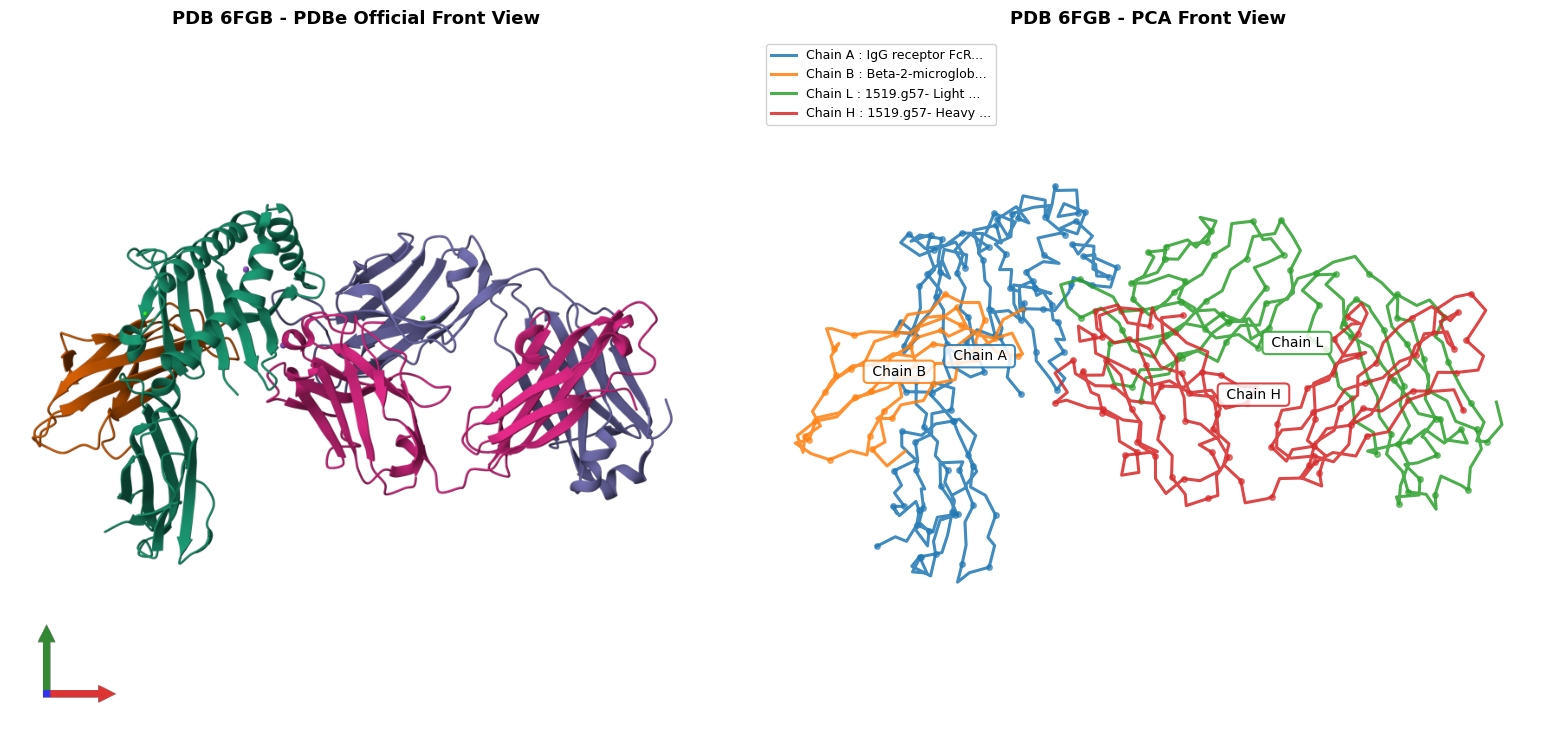

In [ ]:
# 1. PDBe 정적 이미지 로드
pdbe_url = f"https://www.ebi.ac.uk/pdbe/static/entry/{PDB_ID.lower()}_deposited_chain_front_image-800x800.png"
pdbe_path = f"{PDB_ID.upper()}_pdbe_front.png"

pdbe_img = None
try:
    if not os.path.exists(pdbe_path):
        urllib.request.urlretrieve(pdbe_url, pdbe_path)
    if os.path.exists(pdbe_path):
        pdbe_img = plt.imread(pdbe_path)
except Exception:
    pass

# 2. PDBe Front View와 동일한 PCA 주축 계산
all_ca_coords = [atom.coord for atom in structure.get_atoms() if atom.name == 'CA']
if not all_ca_coords:
    all_ca_coords = [atom.coord for atom in structure.get_atoms()]
X = np.array(all_ca_coords)
mean_center = X.mean(axis=0)
Xc = X - mean_center

# SVD를 통한 주성분 벡터(Vt) 산출
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
v_pc1, v_pc2 = Vt[0], Vt[1]

# 3. Side-by-side 시각화 (좌: PDBe 정적 이미지, 우: 동일 각도 Matplotlib 체인 투영)
fig, (ax_img, ax_proj) = plt.subplots(1, 2, figsize=(16, 7.5))

# [좌측] PDBe 고해상도 Cartoon 렌더링
if pdbe_img is not None:
    ax_img.imshow(pdbe_img)
    ax_img.set_title(f"PDB {PDB_ID.upper()} - PDBe Official Front View", fontsize=13, fontweight='bold', pad=10)
    ax_img.axis('off')
else:
    ax_img.text(0.5, 0.5, 'PDBe 이미지 로드 실패', ha='center', va='center')
    ax_img.axis('off')

# [우측] 동일 각도(PCA PC1-PC2 투영) 체인별 백본 및 라벨
colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(chains_in_structure))))

for i, chain in enumerate(chains_in_structure):
    ca_pts = [atom.coord for atom in chain.get_atoms() if atom.name == 'CA']
    if not ca_pts:
        ca_pts = [atom.coord for atom in chain.get_atoms()][::5]
    if not ca_pts:
        continue
        
    pts = np.array(ca_pts) - mean_center
    # PCA 주축으로 투영: x축 = PC1, y축 = PC2
    x_proj = pts @ v_pc1
    y_proj = pts @ v_pc2
    c_color = colors[i % len(colors)]
    
    ent_desc = ''
    for ent in meta.get('entities', []):
        if chain.id in ent['chains']:
            ent_desc = f" : {ent['desc'][:16]}..." if len(ent['desc']) > 16 else f" : {ent['desc']}"
            break
            
    # 체인 선 및 점
    ax_proj.plot(x_proj, y_proj, label=f"Chain {chain.id}{ent_desc}", color=c_color, linewidth=2.2, alpha=0.85)
    ax_proj.scatter(x_proj[::3], y_proj[::3], color=c_color, s=16, alpha=0.6)
    
    # 체인 중심 라벨 박스
    cx, cy = x_proj.mean(), y_proj.mean()
    ax_proj.text(cx, cy, f" Chain {chain.id} ", fontsize=10, color='black',
                 ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor=c_color, linewidth=1.5))

ax_proj.set_title(f"PDB {PDB_ID.upper()} - PCA Front View", fontsize=13, fontweight='bold', pad=10)
ax_proj.axis('off')
ax_proj.set_aspect('equal', 'datalim')
ax_proj.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0), fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.show()

## SASA 계산 함수 정의

- SASA(Solvent Accessible Surface Area): 단백질이나 분자가 용매 (보통 물) 에 노출된 표면의 넓이입니다. 원자 반지름에 탐침 구 (probe sphere, 보통 1.4 Å) 를 굴려서 만들 수 있는 표면적으로 정의됩니다.

> 이 방식의 다른 이름이 Shrake–Rupley 방법인 이유는 원래 SASA를 원자 단위로 효율적으로 계산하는 알고리즘을 제안한 논문 (Shrake & Rupley, 1973) 에서 유래했기 때문입니다.

두 체인 그룹 $A$와 $B$ 사이의 결합 표면적(Buried Surface Area; BSA)은 다음과 같이 계산됩니다:

$$
\text{BSA} = \text{SASA}(\text{Isolated } A) + \text{SASA}(\text{Isolated } B) - \text{SASA}(\text{Complex } A+B)
$$

- BSA(Buried Surface Area): 두 분자가 결합하면서 “숨겨진” 표면의 총량입니다.  
  - $A$와 $B$가 따로 있을 때는 각자의 표면이 모두 용매에 노출되어 있습니다.
  - 결합하면 인터페이스에 있던 일부 표면이 서로 가려져 더 이상 용매에 닿지 않게 됩니다.  
  - 이 “사라진 (묻힌) 표면적”의 합이 BSA 입니다.

그리고 BSA를 2 로 나누면 Interface 면적이 됩니다.

$$
\text{Interface Area} = \frac{\text{BSA}}{2}
$$

- Interface Area: BSA 는 양쪽 분자가 각각 잃은 표면적의 합이므로, 실제 물리적으로 두 분자 사이에 형성된 “공유 인터페이스 면적”을 얻으려면 2 로 나눕니다.  
  - 직관적으로: $A$가 잃은 면적 ≈ $B$가 잃은 면적 ≈ 인터페이스 면적이라고 보면 $\text{BSA} \approx \text{Interface} + \text{Interface} = 2 \times \text{Interface}$이므로 $\text{Interface} = \text{BSA}/2$가 됩니다.

In [5]:
def compute_bsa(pdb_path, chains_a, chains_b):
    """
    임의의 체인 그룹 A와 B 사이의 SASA, BSA, Interface Area를 계산합니다.
    """
    parser = PDBParser(QUIET=True)
    all_target_chains = set(chains_a + chains_b)
    
    # 1. Complex A + B
    struct_c = parser.get_structure("complex", pdb_path)
    model_c = struct_c[0]
    for c in list(model_c):
        if c.id not in all_target_chains:
            model_c.detach_child(c.id)
    sr_c = ShrakeRupley()
    sr_c.compute(struct_c, level="A")
    sasa_complex = sum(a.sasa for c in model_c for r in c for a in r if hasattr(a, 'sasa') and a.sasa is not None)
    
    # 2. Isolated A
    struct_a = parser.get_structure("a", pdb_path)
    model_a = struct_a[0]
    for c in list(model_a):
        if c.id not in set(chains_a):
            model_a.detach_child(c.id)
    sr_a = ShrakeRupley()
    sr_a.compute(struct_a, level="A")
    sasa_a = sum(a.sasa for c in model_a for r in c for a in r if hasattr(a, 'sasa') and a.sasa is not None)
    
    # 3. Isolated B
    struct_b = parser.get_structure("b", pdb_path)
    model_b = struct_b[0]
    for c in list(model_b):
        if c.id not in set(chains_b):
            model_b.detach_child(c.id)
    sr_b = ShrakeRupley()
    sr_b.compute(struct_b, level="A")
    sasa_b = sum(a.sasa for c in model_b for r in c for a in r if hasattr(a, 'sasa') and a.sasa is not None)
    
    bsa = sasa_a + sasa_b - sasa_complex
    interface_area = bsa / 2.0
    
    return {
        'chains_a': chains_a,
        'chains_b': chains_b,
        'sasa_a': sasa_a,
        'sasa_b': sasa_b,
        'sasa_complex': sasa_complex,
        'bsa': bsa,
        'interface_area': interface_area
    }

def print_result_card(title, res):
    print(f"{title} -> BSA: {res['bsa']:,.1f} Å² | Interface Area: {res['interface_area']:,.1f} Å²")

## 비교할 인터페이스 체인 및 라벨 설정

위 단계에서 체인 라벨을 확인한 후, 계산할 체인 그룹과 체인별 커스텀 이름(라벨)을 지정합니다.

💡 설정 안내:

- `GROUP_A_CHAINS`: 첫 번째 파트너 체인 리스트 (예: `["A", "B"]`)
- `GROUP_B_CHAINS`: 두 번째 파트너 체인 리스트 (예: `["E"]` 또는 `["E", "F"]`)
- `CHAIN_LABELS`: 체인별 표시용 커스텀 이름 딕셔너리 (사용자가 원하는 이름으로 자유롭게 지정)
- `CALCULATE_SUBCHAINS`: 그룹 A 내 각 서브체인의 개별 기여도 계산 여부

In [6]:
GROUP_A_CHAINS = ['A', 'B']  # 그룹 A 체인 리스트 (예: ['A', 'B'])
GROUP_B_CHAINS = ['H', 'L']  # 그룹 B 체인 리스트 (예: ['E', 'F'])

# 시각화 시 표시할 체인별 커스텀 이름 (중복 표기를 없애고 원하는 명칭으로 지정)
CHAIN_LABELS = {
    'A': 'FcRn α-chain (A)',
    'B': 'β2M (B)',
    'H': 'IgG1 Fab (H)',
    'L': 'IgG1 Fab (L)',
}

# 서브체인 개별 기여도 계산 여부
CALCULATE_SUBCHAINS = True

# 유효성 검사
invalid_a = [c for c in GROUP_A_CHAINS if c not in all_chains_in_model]
invalid_b = [c for c in GROUP_B_CHAINS if c not in all_chains_in_model]
overlap = set(GROUP_A_CHAINS).intersection(set(GROUP_B_CHAINS))

if invalid_a or invalid_b:
    raise ValueError(f"체인 오류: Model={all_chains_in_model} (미존재: A={invalid_a}, B={invalid_b})")
if overlap:
    raise ValueError(f"중복 체인 오류: {overlap}")

target_b_name = ", ".join([CHAIN_LABELS.get(c, f"Chain {c}") for c in GROUP_B_CHAINS])
print(f"설정: 그룹 A {GROUP_A_CHAINS} vs 그룹 B {GROUP_B_CHAINS} (상대 타겟: {target_b_name})")

설정: 그룹 A ['A', 'B'] vs 그룹 B ['H', 'L'] (상대 타겟: IgG1 Fab (H), IgG1 Fab (L))


## 체인 쌍별(Pairwise) 인터페이스 면적 계산
그룹 A의 체인들과 그룹 B의 체인들 간의 1:1 결합 면적을 모두 계산합니다.
- 전체 복합체 인터페이스: `GROUP_A` vs `GROUP_B`

In [7]:
# 1. 전체 복합체 메인 인터페이스 계산
main_res = compute_bsa(str(pdb_path), GROUP_A_CHAINS, GROUP_B_CHAINS)
print_result_card(f"[전체 복합체] {GROUP_A_CHAINS} vs {GROUP_B_CHAINS}", main_res)
print("-" * 65)

# 2. 그룹 A 체인 x 그룹 B 체인 개별 쌍별 (2 x 2 = 총 4개) 인터페이스 계산
pairwise_results = []

for ch_a in GROUP_A_CHAINS:
    name_a = CHAIN_LABELS.get(ch_a, f"Chain {ch_a}")
    for ch_b in GROUP_B_CHAINS:
        name_b = CHAIN_LABELS.get(ch_b, f"Chain {ch_b}")
        pair_res = compute_bsa(str(pdb_path), [ch_a], [ch_b])
        pair_label = f"{name_a} ↔ {name_b}"
        pairwise_results.append({
            'ch_a': ch_a,
            'ch_b': ch_b,
            'label': pair_label,
            'short_label': f"{ch_a} ↔ {ch_b}",
            'res': pair_res
        })
        print_result_card(f"  [{pair_label}]", pair_res)

[전체 복합체] ['A', 'B'] vs ['H', 'L'] -> BSA: 1,878.8 Å² | Interface Area: 939.4 Å²
-----------------------------------------------------------------
  [FcRn α-chain (A) ↔ IgG1 Fab (H)] -> BSA: 1,309.5 Å² | Interface Area: 654.7 Å²
  [FcRn α-chain (A) ↔ IgG1 Fab (L)] -> BSA: 549.9 Å² | Interface Area: 274.9 Å²
  [β2M (B) ↔ IgG1 Fab (H)] -> BSA: 137.1 Å² | Interface Area: 68.5 Å²
  [β2M (B) ↔ IgG1 Fab (L)] -> BSA: 18.1 Å² | Interface Area: 9.1 Å²


## 체인 쌍별 인터페이스 면적(Interface Area) 파이 차트 시각화

계산된 인터페이스의 실제 결합 면적(Å²)과 상대적 기여율(%)을 도넛 파이 차트로 시각화합니다.

- 접촉이 전혀 없는(면적이 0 Å²인) 체인 쌍은 범례/텍스트에 표시하되 차트 왜곡을 방지합니다.
- 도넛 중앙에는 인터페이스의 총합(Total Interface Area)이 표시됩니다.

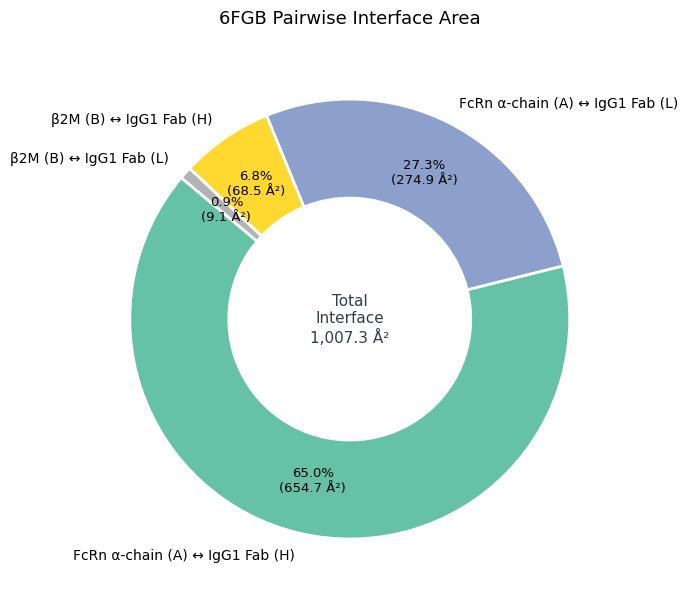

In [8]:
# 면적이 존재하는(0보다 큰) 쌍과 전체 쌍 분리
active_pairs = [p for p in pairwise_results if p['res']['interface_area'] > 0.1]
labels = [p['label'] for p in pairwise_results]
values = [p['res']['interface_area'] for p in pairwise_results]
total_sum = sum(values)

if active_pairs:
    plot_labels = [p['label'] for p in active_pairs]
    plot_values = [p['res']['interface_area'] for p in active_pairs]
    
    # 4개 쌍 구분을 위한 산뜻한 컬러 팔레트
    colors = plt.cm.Set2(np.linspace(0, 1, max(4, len(plot_labels))))
    
    fig, ax = plt.subplots(figsize=(7, 7))
    
    def autopct_fmt(pct):
        val = pct * sum(plot_values) / 100.0
        return f"{pct:.1f}%\n({val:,.1f} Å²)"
    
    wedges, texts, autotexts = ax.pie(
        plot_values,
        labels=plot_labels,
        autopct=autopct_fmt,
        startangle=140,
        colors=colors[:len(plot_labels)],
        pctdistance=0.75,
        wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
    )
    
    plt.setp(texts, fontsize=10)
    plt.setp(autotexts, fontsize=9.5, color='black')
    
    # 도넛 차트 중앙에 총합 Interface Area 표시
    ax.text(0, 0, f"Total\nInterface\n{total_sum:,.1f} Å²", ha='center', va='center',
            fontsize=11, color='#2c3e50')
    
    ax.set_title(f"{PDB_ID.upper()} Pairwise Interface Area",
                 fontsize=13, pad=15)
    plt.tight_layout()
    plt.show()

else:
    print("계산된 인터페이스 면적이 모두 0 Å² 입니다.")

Shrake–Rupley 기반 BSA/Interface 계산은 개념이 직관적이고 구현이 비교적 간단하여 널리 쓰이지만, 탐침 반지름, 샘플링 밀도, 그리고 “Isolated” 상태를 어떻게 구성하느냐에 따라 값이 달라질 수 있으므로 비교 분석 시에는 동일한 파라미터와 조건을 일관되게 유지하는 것이 중요합니다.